In [1]:
import os
import sys
import time
import dask
import zarr
import numpy as np
import xesmf as xe
import xarray as xr
import pandas as pd
from glob import glob

import shutil
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def hourly_datetimes(year: int) -> np.ndarray:
    start = np.datetime64(f"{year}-01-01T00:00:00", "ns")
    stop  = np.datetime64(f"{year+1}-01-01T00:00:00", "ns")  # exclusive
    hours = np.arange(start, stop, np.timedelta64(1, "h"))
    return hours  # dtype: datetime64[ns]

In [5]:
year = 2000
dt_list = hourly_datetimes(year)
flag_soil = False

In [11]:
base_dir = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_FULL/raw_404/'
base_dir_extra = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_FULL/raw_404_new/'

varname_4d = ['WRF_P', 'WRF_Q', 'WRF_T', 'WRF_U', 'WRF_V', 'WRF_Q_tot']

if flag_soil:
    ds_static = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/static/C404_static.zarr')
    
    land = ds_static["LANDMASK"] # 1 = land, 0 = water
    lake = ds_static['LAKEMASK'] # 1 = lake, 0 = land & ocean
    ocean_mask = (land == 0) & (lake == 0) # 1 = ocean
    
    lat2d = ds_static["XLAT"]
    lon2d = ds_static["XLONG"]
    
    # --- xESMF wants its grid as an xarray Dataset -------------------------------
    src_grid = xr.Dataset(
        {
            "lat":  (("y", "x"), lat2d.values),
            "lon":  (("y", "x"), lon2d.values),
            "mask": (("y", "x"), land.values), # 1 = keep, 0 = ignore
        }
    )
    
    # Destination grid is the *same* geometry but **without** the mask
    dst_grid = xr.Dataset({"lat": (("y", "x"), lat2d.values),
                           "lon": (("y", "x"), lon2d.values)})
    
    regridder = xe.Regridder(
        src_grid, dst_grid, 
        method = "bilinear",
        extrap_method = "nearest_s2d",
    )


start_time = time.time() 
fn_year = sorted(glob(base_dir+f'*{year}*.zarr')+glob(base_dir_extra+f'*{year}*.zarr'))

if len(fn_year) > 0:
    file_collect = []
    
    for i_fn, fn in enumerate(fn_year):
        ds = xr.open_zarr(fn)
        ds['time'] = [dt_list[i_fn],]
        file_collect.append(ds)
        
    ds_year = xr.concat(file_collect, dim='time')
    
    # merge all
    ds_year = ds_year.drop_vars(['WRF_Q',])
    
    ds_year['WRF_precip_025'] = ds_year['WRF_precip']**0.25
    ds_year['WRF_radar_composite_025'] = ds_year['WRF_radar_composite']**0.25
    ds_year['WRF_PWAT_05'] = ds_year['WRF_PWAT']**0.5
    ds_year['WRF_Q_tot_05'] = ds_year['WRF_Q_tot']**0.5

    if flag_soil:
        # =================================================== #
        # SMOIS handling
        da_SMOIS = ds_year["WRF_SMOIS"]
        da_SMOIS_land = da_SMOIS.where(land == 1)
        
        da_SMOIS_filled = regridder(da_SMOIS_land, skipna=True,)
        da_SMOIS_filled = da_SMOIS_filled.rename({'y': 'south_north', 'x': 'west_east'})
        da_SMOIS_filled['south_north'] = da_SMOIS['south_north']
        da_SMOIS_filled['west_east'] = da_SMOIS['west_east']
    
        # land vals in da_SMOIS_filled corrected by da_SMOIS
        da_SMOIS_correct = xr.where(land == 1, da_SMOIS, da_SMOIS_filled)
    
        # ocean vals in da_SMOIS_filled corrected by 0.0
        da_SMOIS_correct = xr.where(ocean_mask == 1, 0.0, da_SMOIS_correct)
        da_SMOIS_correct = da_SMOIS_correct.transpose("time", "south_north", "west_east")
        
        ds_year["WRF_SMOIS"] = da_SMOIS_correct
        
        # =================================================== #
        # TSLB handling
        da_TSLB = ds_year["WRF_TSLB"]
        da_TSLB_land = da_TSLB.where(lake == 0)
        
        da_TSLB_filled = regridder(da_TSLB_land, skipna=True,)
        da_TSLB_filled = da_TSLB_filled.rename({'y': 'south_north', 'x': 'west_east'})
        da_TSLB_filled['south_north'] = da_TSLB['south_north']
        da_TSLB_filled['west_east'] = da_TSLB['west_east']
    
        # non-lake vals in da_TSLB_filled corrected by da_TSLB
        da_TSLB_correct = xr.where(lake == 0, da_TSLB, da_TSLB_filled)
        da_TSLB_correct = da_TSLB_correct.transpose("time", "south_north", "west_east")
    
        ds_year["WRF_TSLB"] = da_TSLB_correct

    # =================================================== #
    # rechunk
    ds_year = ds_year.chunk(
        {
            'time': 16, 
            'bottom_top': 12, 
            'pressure_approx': 12, 
            'south_north': 1015, 
            'west_east': 1367
        }
    )
    
    varnames = list(ds_year.keys())
    # zarr encodings
    dict_encoding = {}
    
    chunk_size_3d = dict(chunks=(16, 1015, 1367))
    chunk_size_4d = dict(chunks=(16, 12, 1015, 1367))
    
    compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)
    
    for i_var, var in enumerate(varnames):
        if var in varname_4d:
            dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
        else:
            dict_encoding[var] = {'compressor': compress, **chunk_size_3d}
    
    save_name = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404/C404_FULL_{year}.zarr'
    ds_year.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)
    print(save_name)
    print("--- %s seconds ---" % (time.time() - start_time))
else:
    print(f'Skip year {year}')

/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404/C404_FULL_2000.zarr
--- 11.390315532684326 seconds ---


In [3]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404/C404_FULL_2000.zarr')

In [4]:
ds

<xarray.Dataset> Size: 6TB
Dimensions:                  (time: 8784, south_north: 1015, west_east: 1367,
                              bottom_top: 12, pressure_approx: 12)
Coordinates:
  * bottom_top               (bottom_top) float32 48B 0.0 1.0 2.0 ... 10.0 11.0
  * pressure_approx          (pressure_approx) float32 48B 1e+03 946.0 ... 100.0
  * south_north              (south_north) float32 4kB 0.0 1.0 ... 1.014e+03
  * time                     (time) datetime64[ns] 70kB 2000-01-01 ... 2000-1...
  * west_east                (west_east) float32 5kB 0.0 1.0 ... 1.366e+03
Data variables: (12/27)
    WRF_GLW                  (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_OLR                  (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_P                    (time, bottom_top, south_north, west_east) float32 585GB dask.array<chunksize=(16, 12, 1015, 1367), meta=np.ndarray>
    WRF_PWAT                 (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_PWAT_05              (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_Q_tot                (time, bottom_top, south_north, west_east) float32 585GB dask.array<chunksize=(16, 12, 1015, 1367), meta=np.ndarray>
    ...                       ...
    WRF_Z                    (time, bottom_top, south_north, west_east) float32 585GB dask.array<chunksize=(16, 12, 1015, 1367), meta=np.ndarray>
    WRF_evapor               (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_precip               (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_precip_025           (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_radar_composite      (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>
    WRF_radar_composite_025  (time, south_north, west_east) float32 49GB dask.array<chunksize=(16, 1015, 1367), meta=np.ndarray>

## 8 km grids

In [6]:
year = 2000
ds = xr.open_zarr(f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404/C404_FULL_{year}.zarr')

In [7]:
ds_8km = ds.coarsen(south_north=2, west_east=2, boundary="trim").mean()

In [10]:
varname_4d = ['WRF_P', 'WRF_Q', 'WRF_T', 'WRF_U', 'WRF_V', 'WRF_Q_tot']
# =================================================== #
# rechunk
ds_8km = ds_8km.chunk(
    {
        'time': 16, 
        'bottom_top': 12, 
        'pressure_approx': 12, 
        'south_north': -1, 
        'west_east': -1
    }
)

varnames = list(ds_8km.keys())
# zarr encodings
dict_encoding = {}

chunk_size_3d = dict(chunks=(16, -1, -1))
chunk_size_4d = dict(chunks=(16, 12, -1, -1))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    if var in varname_4d:
        dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
    else:
        dict_encoding[var] = {'compressor': compress, **chunk_size_3d}

In [11]:
save_name = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404_8km/C404_8km_{year}.zarr'

In [12]:
# ds_8km.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)


KeyboardInterrupt



## QC

In [4]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404/C404_FULL_2021.zarr')

In [3]:
ds = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_FULL/C404_8km/C404_8km_2000.zarr')

In [4]:
T2 = ds['WRF_T2'].isel(time=999).values

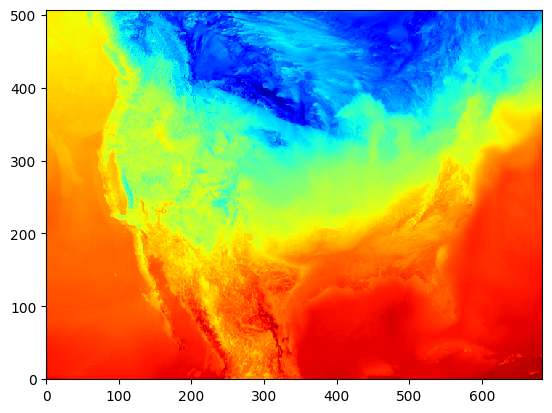

In [5]:
plt.pcolormesh(T2, cmap=plt.cm.jet)